In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
import pymysql
from db_config import DB_HOST, DB_USER, DB_PASSWD, DB_NAME

try:
    with pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASSWD,
        database=DB_NAME
        # Notice I deleted the DictCursor line here!
    ) as connection:
        query = "SELECT id, ts, temp_dht, pm1, pm25, pm10 FROM project_kidbright_outdoor where id <= 7131"
        df = pd.read_sql(query, connection)
        
        # Save it to CSV so we never deal with the DB again tonight
        # df.to_csv("aqi_data.csv", index=False)
        print("Data saved to CSV. Connection closed automatically.")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data saved to CSV. Connection closed automatically.


/var/folders/x9/j5dq5m9n5_ddggn66zklqbv80000gn/T/ipykernel_1429/3375557088.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,ts,temp_dht,pm1,pm25,pm10
0,1,2026-03-27 21:50:28,0,0,0,0
1,2,2026-03-27 21:51:22,0,0,0,0
2,3,2026-03-27 21:51:38,0,0,0,0
3,4,2026-03-27 21:51:53,0,0,0,0
4,5,2026-03-27 21:53:09,0,49,62,73


In [41]:
df.shape

(7131, 6)

In [42]:
# information about the dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7131 entries, 0 to 7130
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        7131 non-null   int64         
 1   ts        7131 non-null   datetime64[us]
 2   temp_dht  7131 non-null   int64         
 3   pm1       7131 non-null   int64         
 4   pm25      7131 non-null   int64         
 5   pm10      7131 non-null   int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 334.4 KB
None


In [43]:
df.nunique()

id          7131
ts          7131
temp_dht      11
pm1           31
pm25          39
pm10          44
dtype: int64

In [44]:
df.describe()

,id,ts,temp_dht,pm1,pm25,pm10
count,7131.000000,7131,7131.000000,7131.000000,7131.000000,7131.000000
mean,3566.000000,2026-03-30 09:22:59.010798,30.629785,8.956808,15.090029,15.710560
min,1.000000,2026-03-27 21:50:28,0.000000,0.000000,0.000000,0.000000
25%,1783.500000,2026-03-29 03:31:38,29.000000,0.000000,0.000000,0.000000
50%,3566.000000,2026-03-30 09:23:01,30.000000,10.000000,16.000000,17.000000
75%,5348.500000,2026-03-31 15:14:24,33.000000,14.000000,24.000000,25.000000
max,7131.000000,2026-04-01 21:05:48,36.000000,49.000000,62.000000,73.000000
std,2058.686717,NaN,3.824125,7.311317,12.258095,12.827689


In [45]:
#group data
df = df.drop(columns=['id'])

# 2. Convert 'ts' to datetime objects
df['ts'] = pd.to_datetime(df['ts'])

# 3. Set 'ts' as index and resample to 10-minute intervals, calculating the mean
df = df.set_index('ts').resample('10min').mean()

# Reset index so 'ts' becomes a column again
df = df.reset_index()

print(df)

                     ts   temp_dht        pm1       pm25       pm10
0   2026-03-27 21:50:00   2.636364  13.727273  18.000000  19.272727
1   2026-03-27 22:00:00   0.000000  14.592593  22.111111  23.555556
2   2026-03-27 22:10:00   0.000000  17.928571  26.000000  26.785714
3   2026-03-27 22:20:00   0.000000  23.714286  31.500000  33.214286
4   2026-03-27 22:30:00        NaN        NaN        NaN        NaN
..                  ...        ...        ...        ...        ...
711 2026-04-01 20:20:00  31.000000   7.000000  12.200000  13.200000
712 2026-04-01 20:30:00  31.000000   3.900000   6.900000   7.000000
713 2026-04-01 20:40:00  31.000000  10.100000  16.300000  16.600000
714 2026-04-01 20:50:00  30.300000   7.300000  12.800000  13.900000
715 2026-04-01 21:00:00  30.000000  12.500000  22.666667  23.000000

[716 rows x 5 columns]


In [46]:
null_counts = df.isnull().sum()
zero_counts = (df == 0).sum()
blank_counts = (df == '').sum()
bad_pm_count = ((df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)).sum()
impossible_pm_logic = (df['pm25'] > df['pm10']).sum()
print(f"{null_counts}\n\n{zero_counts}\n\n{blank_counts}\n\n{bad_pm_count}\n\n{impossible_pm_logic}")

ts          0
temp_dht    1
pm1         1
pm25        1
pm10        1
dtype: int64

ts          0
temp_dht    3
pm1         9
pm25        9
pm10        9
dtype: int64

ts          0
temp_dht    0
pm1         0
pm25        0
pm10        0
dtype: int64

32

0


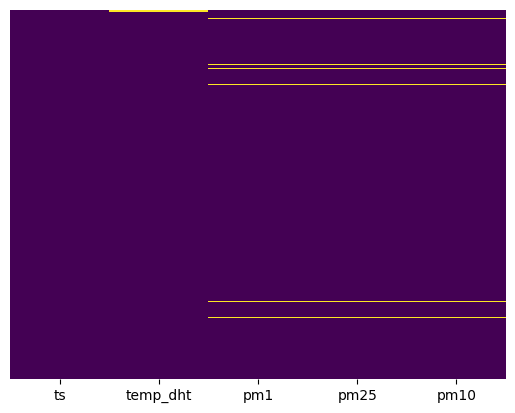

In [47]:
sns.heatmap(df.isnull()|(df == 0) | (df == ''), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

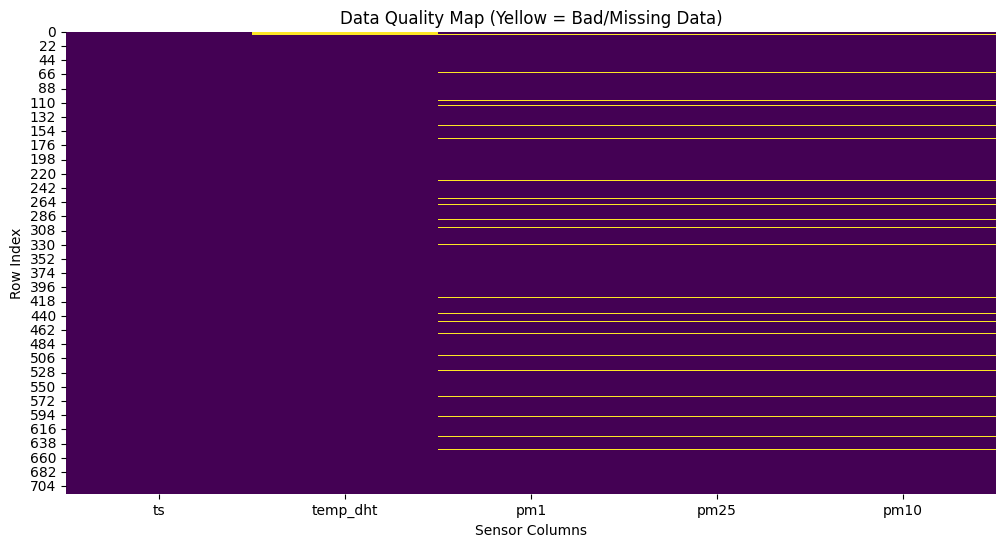

In [48]:
is_bad = df.isnull() | (df == 0) | (df == '')

# 2. Add your specific logic for PM values < 5
# This identifies rows where all PM sensors are below 5
pm_low_mask = (df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)

# We mark these specific rows as 'bad' in the PM columns
for col in ['pm1', 'pm25', 'pm10']:
    is_bad[col] = is_bad[col] | pm_low_mask

# 3. Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(is_bad, cbar=False, cmap='viridis')

plt.title('Data Quality Map (Yellow = Bad/Missing Data)')
plt.xlabel('Sensor Columns')
plt.ylabel('Row Index')
plt.show()

In [49]:
df = df.replace(0, np.nan)
df = df.replace("", np.nan)
pm_bad_mask = (df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)
df.loc[pm_bad_mask, ['pm1', 'pm25', 'pm10']] = np.nan

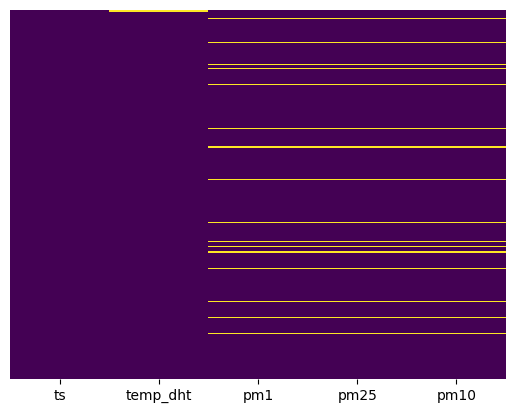

In [50]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [51]:
df = df.dropna()
df.head()

,ts,temp_dht,pm1,pm25,pm10
0,2026-03-27 21:50:00,2.636364,13.727273,18.000000,19.272727
5,2026-03-27 22:40:00,29.000000,12.600000,17.600000,18.000000
6,2026-03-27 22:50:00,29.000000,32.111111,39.666667,46.333333
7,2026-03-27 23:00:00,29.000000,10.000000,20.400000,21.900000
8,2026-03-27 23:10:00,29.000000,11.500000,21.800000,22.600000


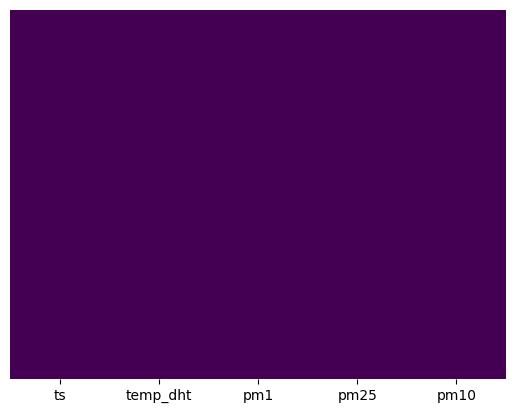

In [52]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

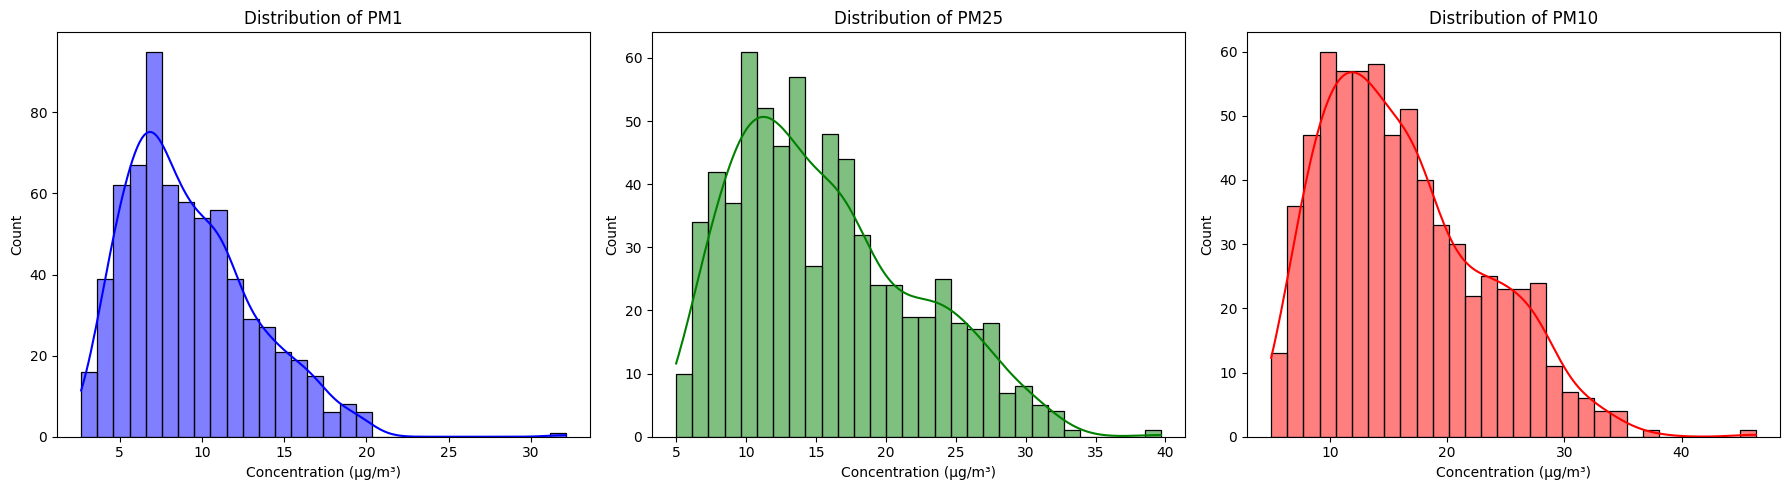

In [53]:
# Create a figure for the 3 histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pm_list = ['pm1', 'pm25', 'pm10']
colors = ['blue', 'green', 'red']

for i, col in enumerate(pm_list):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {col.upper()}')
    axes[i].set_xlabel('Concentration (µg/m³)')

plt.tight_layout()
plt.show()

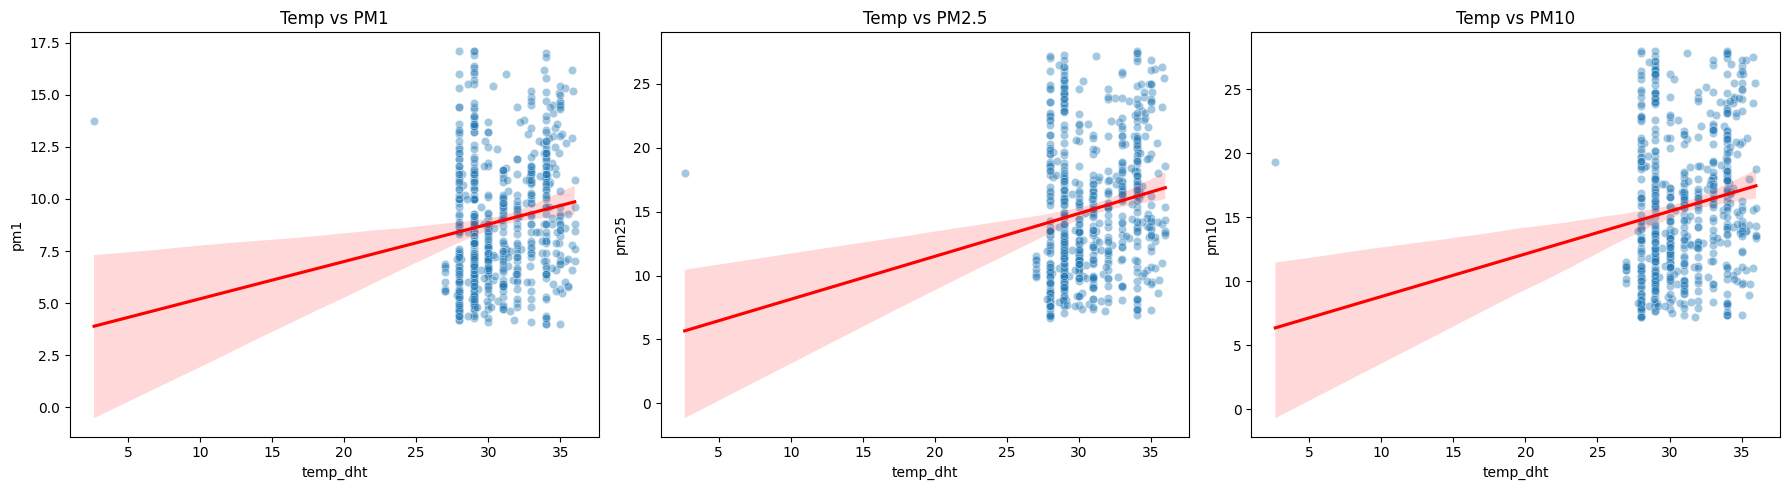

In [61]:
# 3. Create a 1x3 Grid for Scatters - Temperature vs PM sensors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperature vs PM sensors
sns.scatterplot(data=df, x='temp_dht', y='pm1', ax=axes[0], alpha=0.4).set_title('Temp vs PM1')
sns.scatterplot(data=df, x='temp_dht', y='pm25', ax=axes[1], alpha=0.4).set_title('Temp vs PM2.5')
sns.scatterplot(data=df, x='temp_dht', y='pm10', ax=axes[2], alpha=0.4).set_title('Temp vs PM10')

# Add trend lines to all to see the direction of correlation
for ax in axes.flat:
    sns.regplot(data=df, x=ax.get_xlabel(), y=ax.get_ylabel(), ax=ax, scatter=False, color='red')

plt.tight_layout()
plt.show()

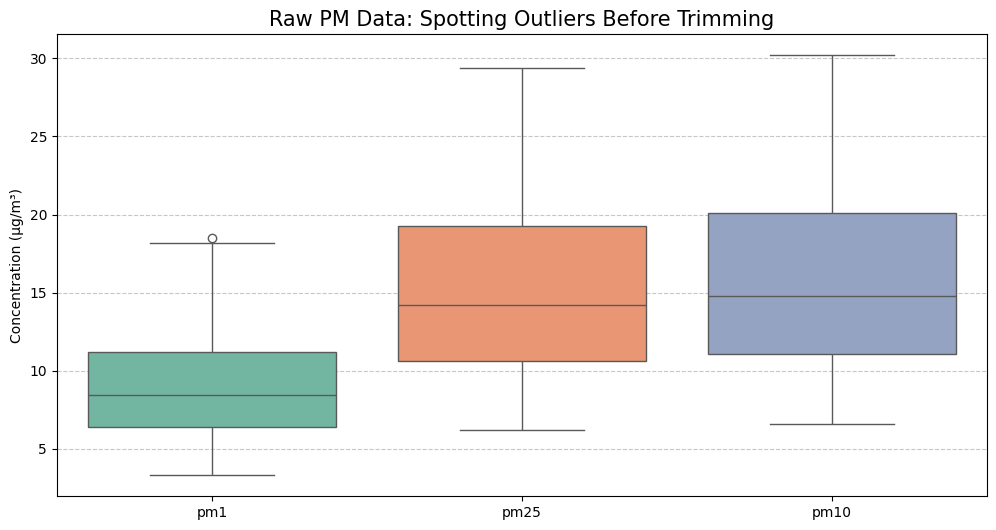

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns we're looking at
pm_cols = ['pm1', 'pm25', 'pm10']

# Create the figure
plt.figure(figsize=(12, 6))

# Use seaborn to create the boxplots
# We use orient='h' to make them horizontal, or leave it for vertical
sns.boxplot(data=df[pm_cols], palette="Set2")

plt.title('Raw PM Data: Spotting Outliers Before Trimming', fontsize=15)
plt.ylabel('Concentration (µg/m³)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

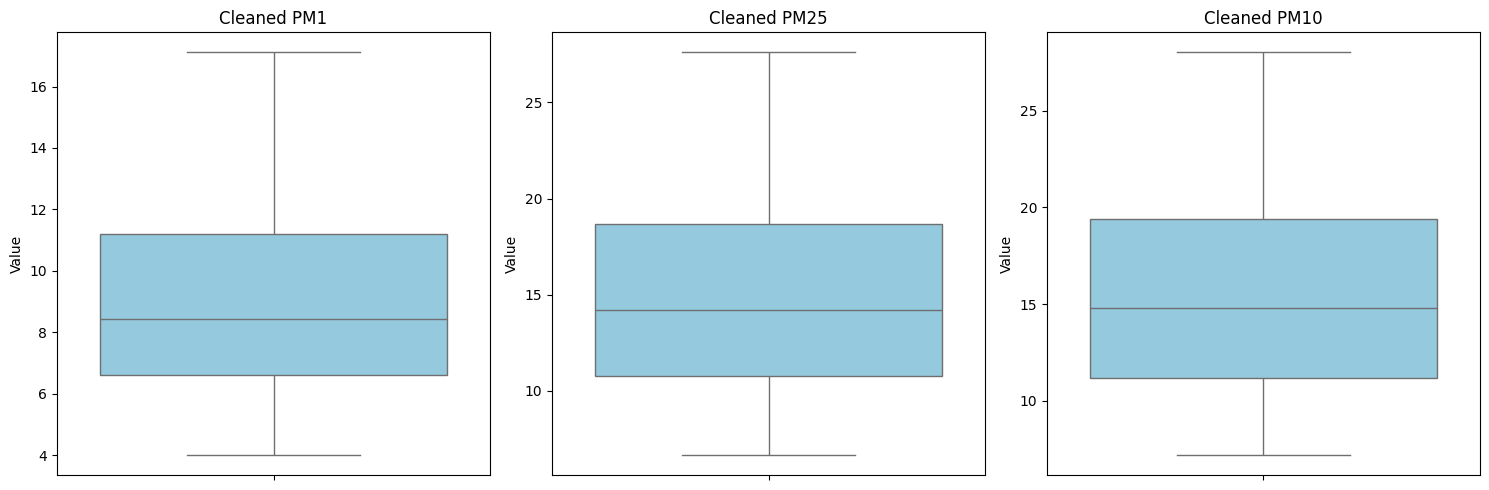

Outliers removed. Remaining data points: 606


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the PM columns
pm_cols = ['pm1', 'pm25', 'pm10']

# 2. Remove outliers (1st and 99th percentiles)
for col in pm_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 3. Create 3 boxplots to visualize the cleaned data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(pm_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Cleaned {col.upper()}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

print(f"Outliers removed. Remaining data points: {len(df)}")

In [57]:
df.to_csv("outdoor.csv",index=False)